# Thesis Notebook 5 — Primary Survey Data Analysis
**Dissertation:** Predictive Query Rate Modelling in Clinical Trials: A Machine Learning Framework for Data Quality Risk Scoring  
**Student:** Puneetha Chowdari Modepalli Subramanyam Reddamma  
**Institution:** Berlin School of Business and Innovation (BSBI)  
**Chapter:** Chapter Three — Methodology (Primary Research Findings)  

## Purpose
This notebook analyses the primary survey data collected from 20 clinical data management (CDM) professionals via Google Forms (June–July 2026). It produces 8 publication-quality figures for inclusion in the dissertation methodology and findings chapters.

## Survey Overview
- **n = 20 respondents**
- **Distribution:** LinkedIn professional network (CDM/clinical research professionals)
- **Period:** 26 June – 21 July 2026
- **Sections:** Participant profile | Query rate drivers (Likert) | Current practices | ML familiarity | Open feedback

## Cell 1 — Import Libraries and Load Survey Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette — professional dark blue theme ────────────
C_DARK  = '#1F3864'
C_MID   = '#2E75B6'
C_LIGHT = '#9DC3E6'
C_TEAL  = '#00B0A0'
C_GREEN = '#1E6B1E'
C_AMBER = '#C8930A'
C_RED   = '#C00000'
C_GRAY  = '#808080'
C_LGRAY = '#F2F2F2'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 180,
})

# ── Load CSV ─────────────────────────────────────────────────
CSV_PATH = "C:/Users/Puni/Desktop/Thesis/Dataset/Data Quality Risk Factors in Clinical Trials — Expert Survey.csv"

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
df.columns = [c.strip() for c in df.columns]
N = len(df)

print(f'Survey loaded successfully')
print(f'Total respondents: {N}')
print(f'Total columns: {len(df.columns)}')
print(f'\nColumn list:')
for i, col in enumerate(df.columns):
    print(f'  [{i}] {col[:80]}')

Survey loaded successfully
Total respondents: 20
Total columns: 33

Column list:
  [0] Timestamp
  [1] Q1. How many years of experience do you have in clinical data management or clin
  [2] Q2. What best describes your current or most recent role?
  [3] Q3. What type of organisation do you currently or most recently work for?
  [4] Q4. Which EDC system(s) have you worked with? Select all that apply.
  [5] Q5. In your professional experience, how strongly does each of the following fac
  [6] Q5. In your professional experience, how strongly does each of the following fac
  [7] Q5. In your professional experience, how strongly does each of the following fac
  [8] Q5. In your professional experience, how strongly does each of the following fac
  [9] Q5. In your professional experience, how strongly does each of the following fac
  [10] Q5. In your professional experience, how strongly does each of the following fac
  [11] Q5. In your professional experience, how strongly does each of the 

## Cell 2 — Define Question Mappings and Score Map

In [3]:
# ── Likert score mapping ──────────────────────────────────────
score_map = {
    '1 — Not at all influential': 1,
    '2 — Slightly influential': 2,
    '3 — Moderately influential': 3,
    '4 — Very influential': 4,
    '5 — Extremely influential': 5
}

# ── Factor names matching the survey question order (Q5) ─────
# These correspond to columns 5 to 14 (0-indexed)
factor_names = [
    'CRF complexity /\npage count',
    'Protocol amendment\nfrequency',
    'Screen failure rate',
    'Site experience level',
    'Therapeutic area\ncomplexity',
    'Trial phase (I–IV)',
    'No. of enrolled\nparticipants',
    'No. of study sites',
    'Edit check density\nin EDC',
    'Trial duration'
]
factor_col_indices = list(range(5, 15))  # Q5 spans columns 5-14

# ── Compute Likert means and standard deviations ─────────────
means, stds = [], []
for col_idx in factor_col_indices:
    col = df.columns[col_idx]
    scores = df[col].map(score_map).dropna()
    means.append(scores.mean())
    stds.append(scores.std())

# Create summary DataFrame
factor_summary = pd.DataFrame({
    'Factor': [f.replace('\n', ' ') for f in factor_names],
    'Mean Score': means,
    'Std Dev': stds,
    'Rank': pd.Series(means).rank(ascending=False).astype(int)
}).sort_values('Mean Score', ascending=False)

print('Q5 Likert Scores Summary:')
print(factor_summary.to_string(index=False))

Q5 Likert Scores Summary:
                      Factor  Mean Score  Std Dev  Rank
 Therapeutic area complexity        3.95 1.145931     1
 CRF complexity / page count        3.85 1.136708     2
   Edit check density in EDC        3.80 1.056309     3
Protocol amendment frequency        3.60 1.046297     4
       Site experience level        3.60 1.313893     4
No. of enrolled participants        3.45 1.394538     6
          No. of study sites        3.45 1.190975     6
          Trial phase (I–IV)        3.40 1.273206     8
              Trial duration        3.30 1.174286     9
         Screen failure rate        3.10 1.372665    10


## Cell 3 — Figure 4.1: Respondent Profile

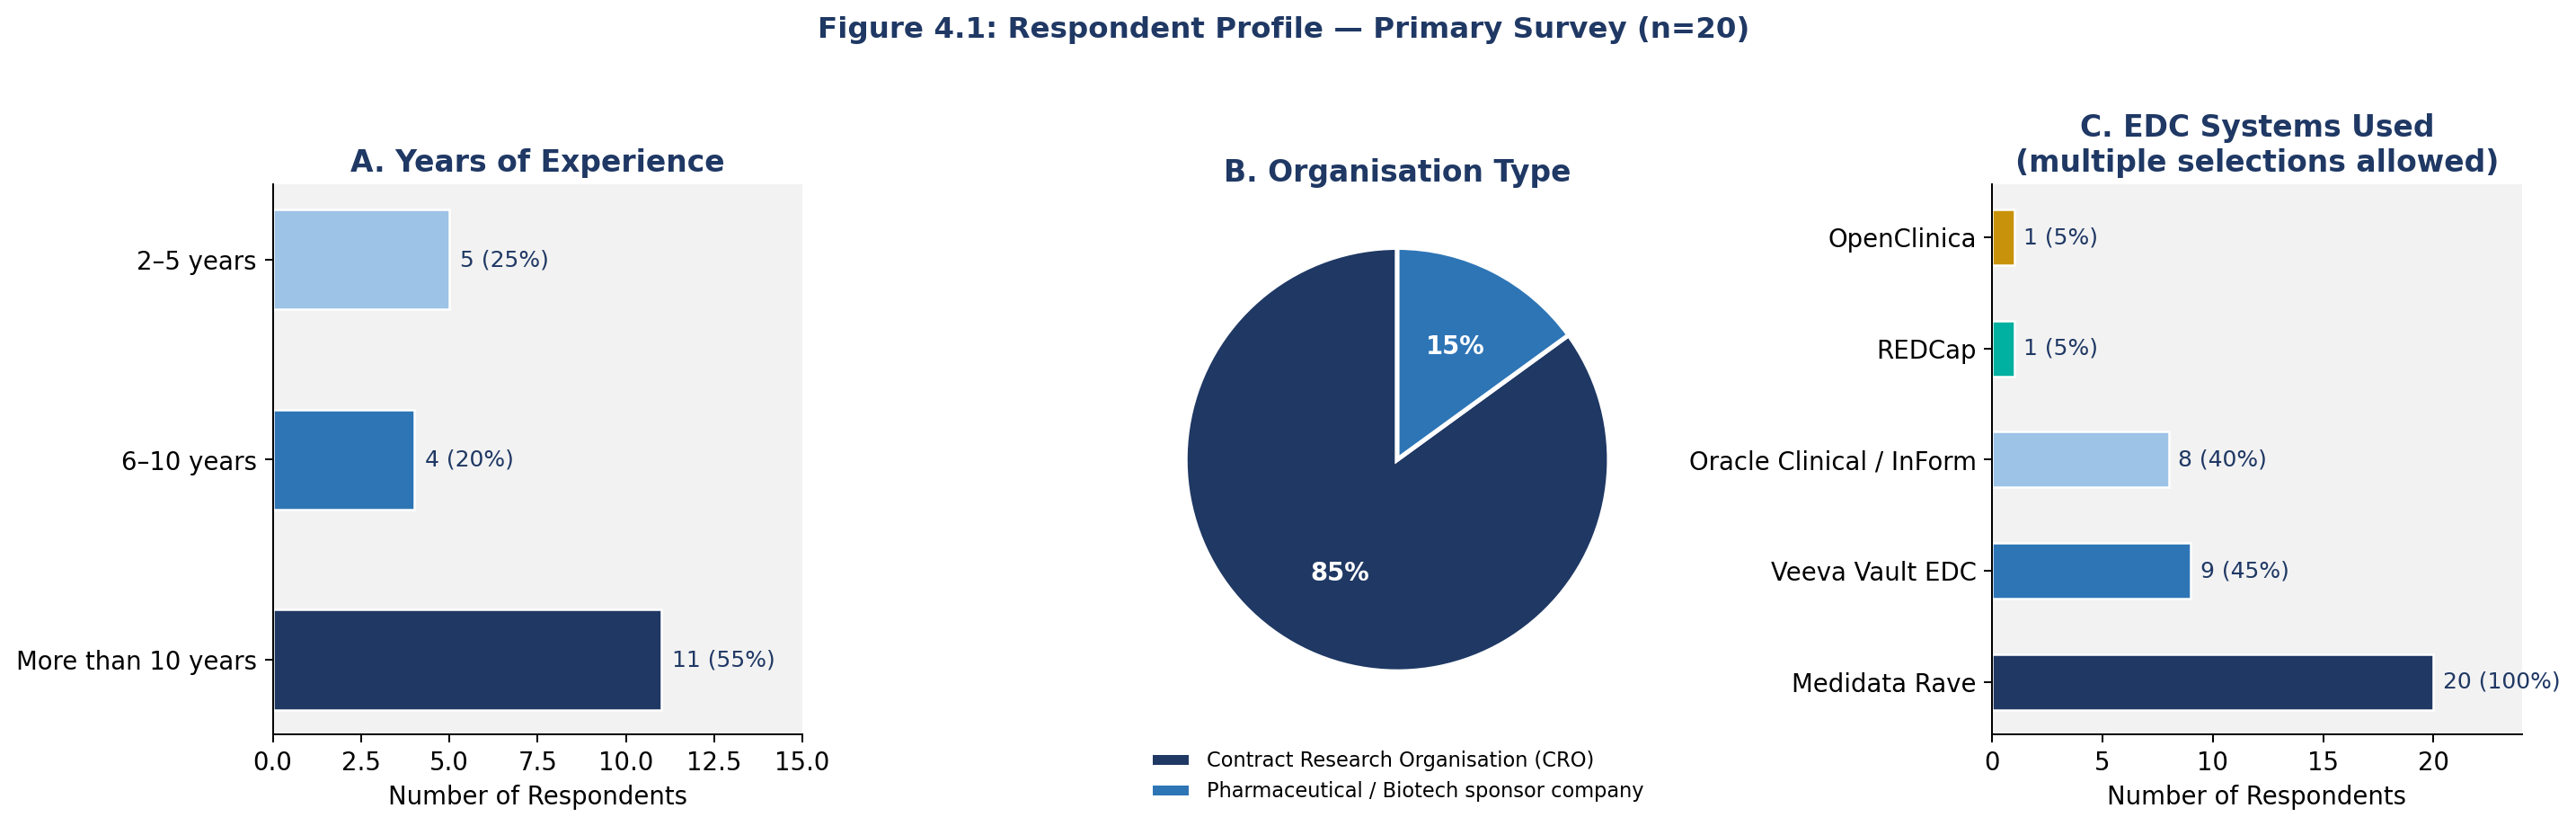

Figure 4.1 saved


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Figure 4.1: Respondent Profile — Primary Survey (n={N})',
             fontsize=13, fontweight='bold', color=C_DARK, y=1.02)

# Panel A — Years of Experience (col 1)
exp_data = df.iloc[:, 1].value_counts()
exp_order = ['More than 10 years', '6–10 years', '2–5 years']
exp_vals  = [exp_data.get(k, 0) for k in exp_order]
bars = axes[0].barh(exp_order, exp_vals,
                    color=[C_DARK, C_MID, C_LIGHT],
                    edgecolor='white', height=0.5)
for bar, val in zip(bars, exp_vals):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f' {val} ({val/N*100:.0f}%)', va='center', fontsize=10, color=C_DARK)
axes[0].set_title('A. Years of Experience', fontweight='bold', color=C_DARK)
axes[0].set_xlabel('Number of Respondents')
axes[0].set_xlim(0, 15)
axes[0].set_facecolor(C_LGRAY)

# Panel B — Organisation Type (col 3)
org_data = df.iloc[:, 3].value_counts()
wedges, texts, autotexts = axes[1].pie(
    org_data.values, labels=None,
    colors=[C_DARK, C_MID],
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
axes[1].legend(list(org_data.index), loc='lower center', fontsize=9,
               frameon=False, bbox_to_anchor=(0.5, -0.18))
axes[1].set_title('B. Organisation Type', fontweight='bold', color=C_DARK)

# Panel C — EDC Systems (col 4, multi-select)
edc_order = ['Medidata Rave', 'Veeva Vault EDC', 'Oracle Clinical / InForm', 'REDCap', 'OpenClinica']
edc_vals  = [df.iloc[:, 4].str.contains(edc, na=False).sum() for edc in edc_order]
bars_c = axes[2].barh(edc_order, edc_vals,
                      color=[C_DARK, C_MID, C_LIGHT, C_TEAL, C_AMBER],
                      edgecolor='white', height=0.5)
for bar, val in zip(bars_c, edc_vals):
    axes[2].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f' {val} ({val/N*100:.0f}%)', va='center', fontsize=10, color=C_DARK)
axes[2].set_title('C. EDC Systems Used\n(multiple selections allowed)', fontweight='bold', color=C_DARK)
axes[2].set_xlabel('Number of Respondents')
axes[2].set_xlim(0, 24)
axes[2].set_facecolor(C_LGRAY)

plt.tight_layout()
plt.savefig('Fig4_1_Respondent_Profile.jpg', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4.1 saved')

## Cell 4 — Figure 4.2: Likert Mean Scores (Horizontal Bar)

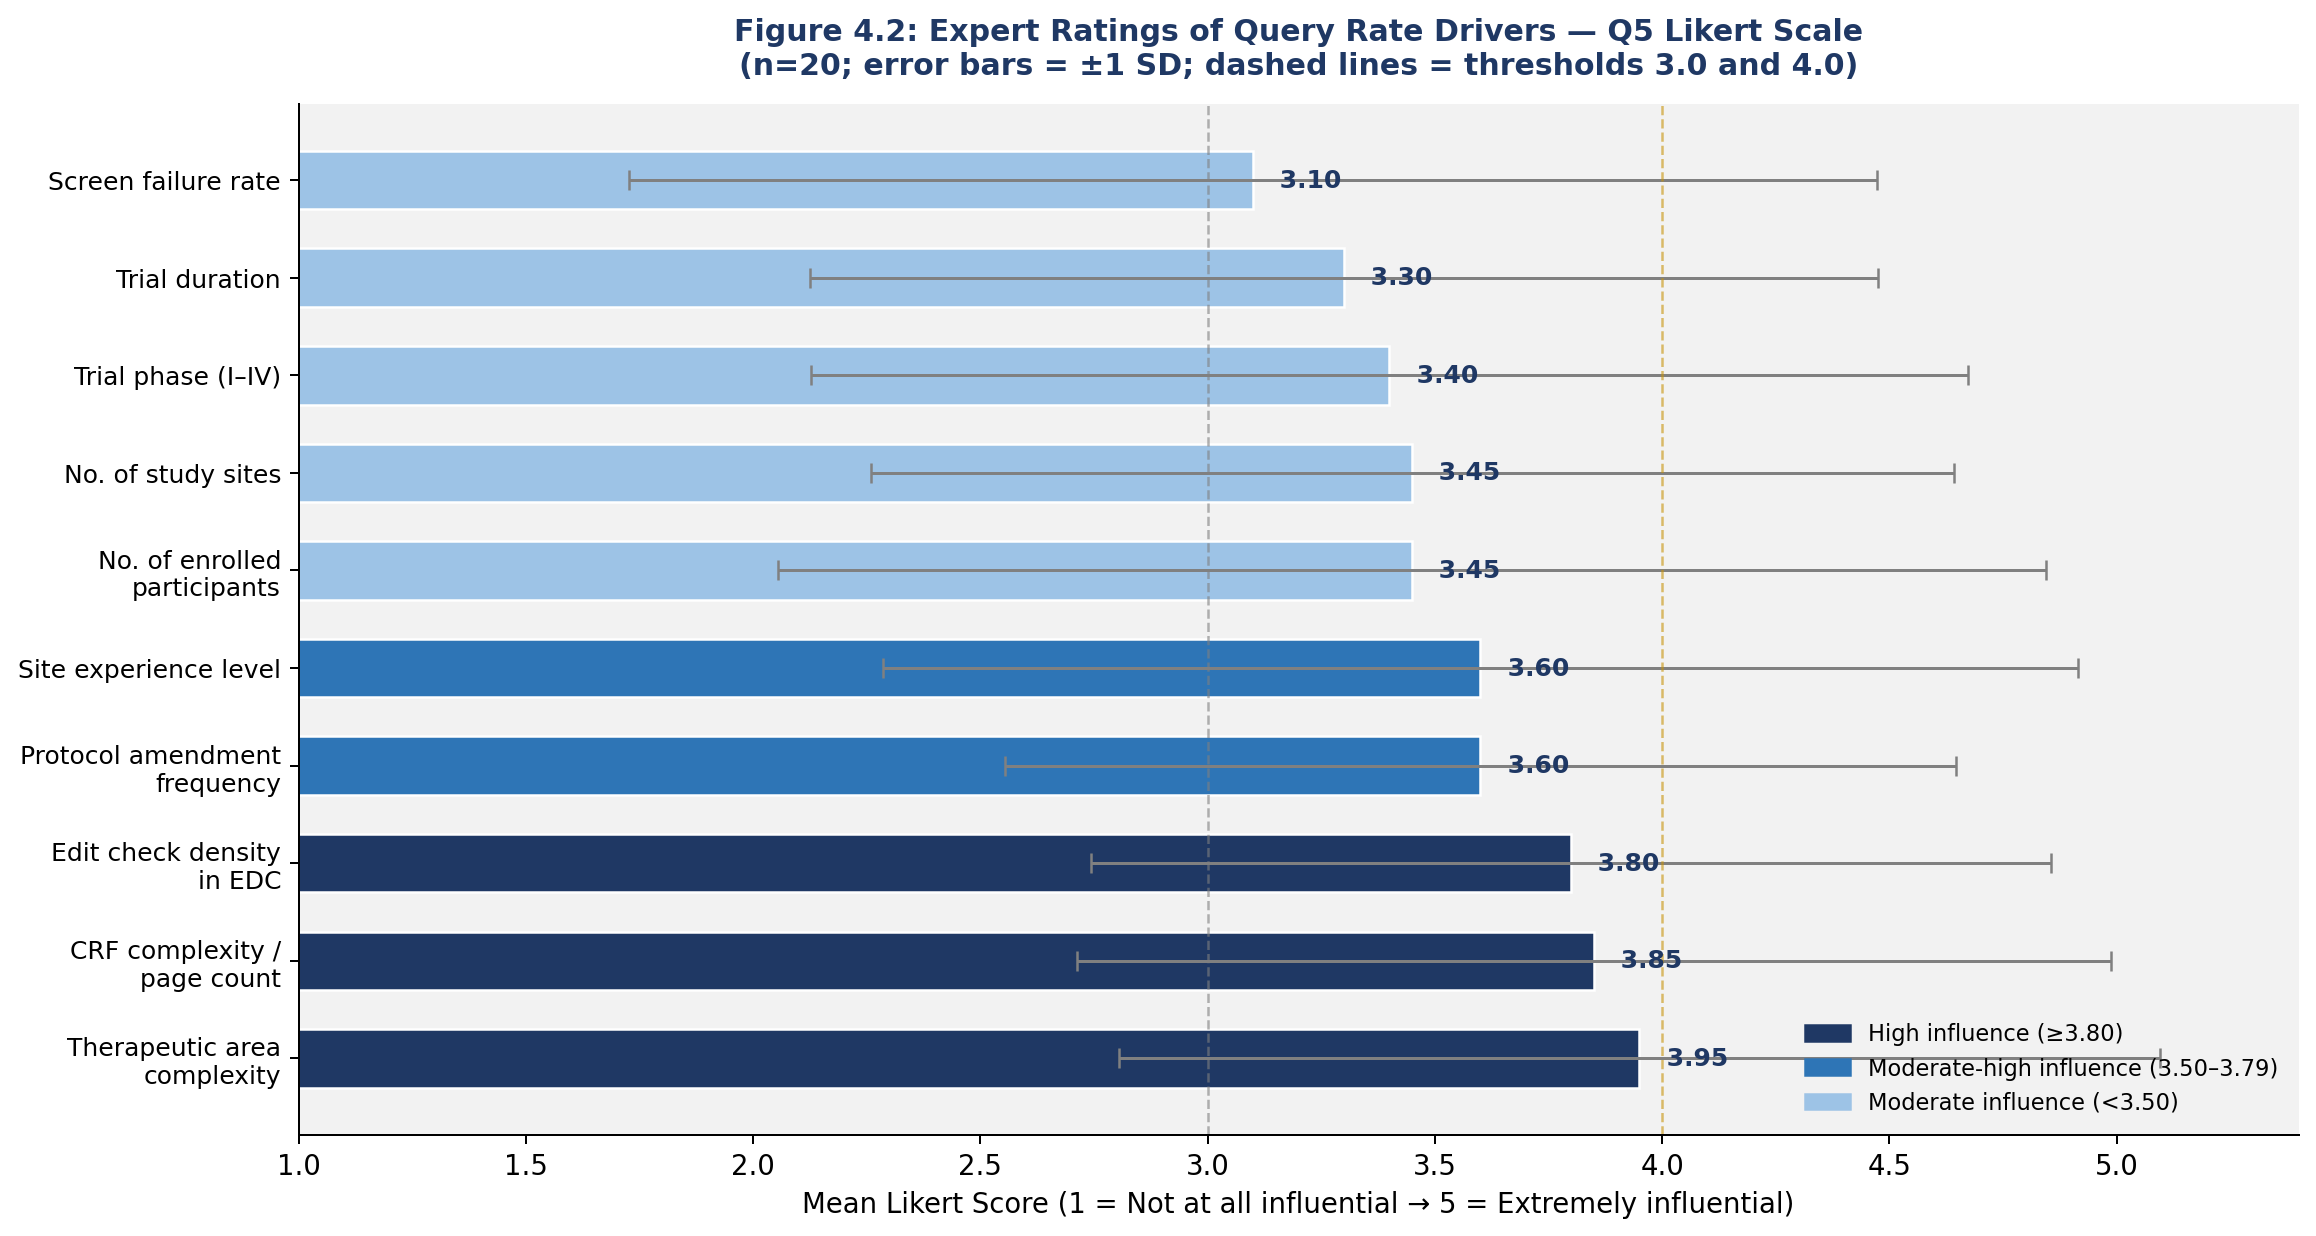

Figure 4.2 saved


In [5]:
fig, ax = plt.subplots(figsize=(13, 7))

# Sort factors by mean score descending
sorted_data = sorted(zip(factor_names, means, stds), key=lambda x: -x[1])
s_names = [x[0] for x in sorted_data]
s_means = [x[1] for x in sorted_data]
s_stds  = [x[2] for x in sorted_data]

# Colour by influence level
colors = [C_DARK if m >= 3.8 else (C_MID if m >= 3.5 else C_LIGHT) for m in s_means]

bars = ax.barh(s_names, s_means, xerr=s_stds, color=colors,
               edgecolor='white', height=0.6,
               error_kw=dict(ecolor=C_GRAY, capsize=4, linewidth=1.2))

# Reference threshold lines
ax.axvline(x=3.0, color=C_GRAY, linestyle='--', linewidth=1, alpha=0.6, label='Moderate (3.0)')
ax.axvline(x=4.0, color=C_AMBER, linestyle='--', linewidth=1, alpha=0.6, label='Very influential (4.0)')

# Value labels
for bar, mean in zip(bars, s_means):
    ax.text(bar.get_width()+0.04, bar.get_y()+bar.get_height()/2,
            f' {mean:.2f}', va='center', fontsize=10, color=C_DARK, fontweight='bold')

ax.set_xlabel('Mean Likert Score (1 = Not at all influential → 5 = Extremely influential)', fontsize=11)
ax.set_title(
    f'Figure 4.2: Expert Ratings of Query Rate Drivers — Q5 Likert Scale\n'
    f'(n={N}; error bars = ±1 SD; dashed lines = thresholds 3.0 and 4.0)',
    fontsize=12, fontweight='bold', color=C_DARK, pad=12
)
ax.set_xlim(1, 5.4)
ax.set_facecolor(C_LGRAY)

patches = [
    mpatches.Patch(color=C_DARK,  label='High influence (≥3.80)'),
    mpatches.Patch(color=C_MID,   label='Moderate-high influence (3.50–3.79)'),
    mpatches.Patch(color=C_LIGHT, label='Moderate influence (<3.50)'),
]
ax.legend(handles=patches, fontsize=9, frameon=False, loc='lower right')
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('Fig4_2_Likert_Scores.jpg', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4.2 saved')

## Cell 5 — Figure 4.3: Stacked Likert Distribution

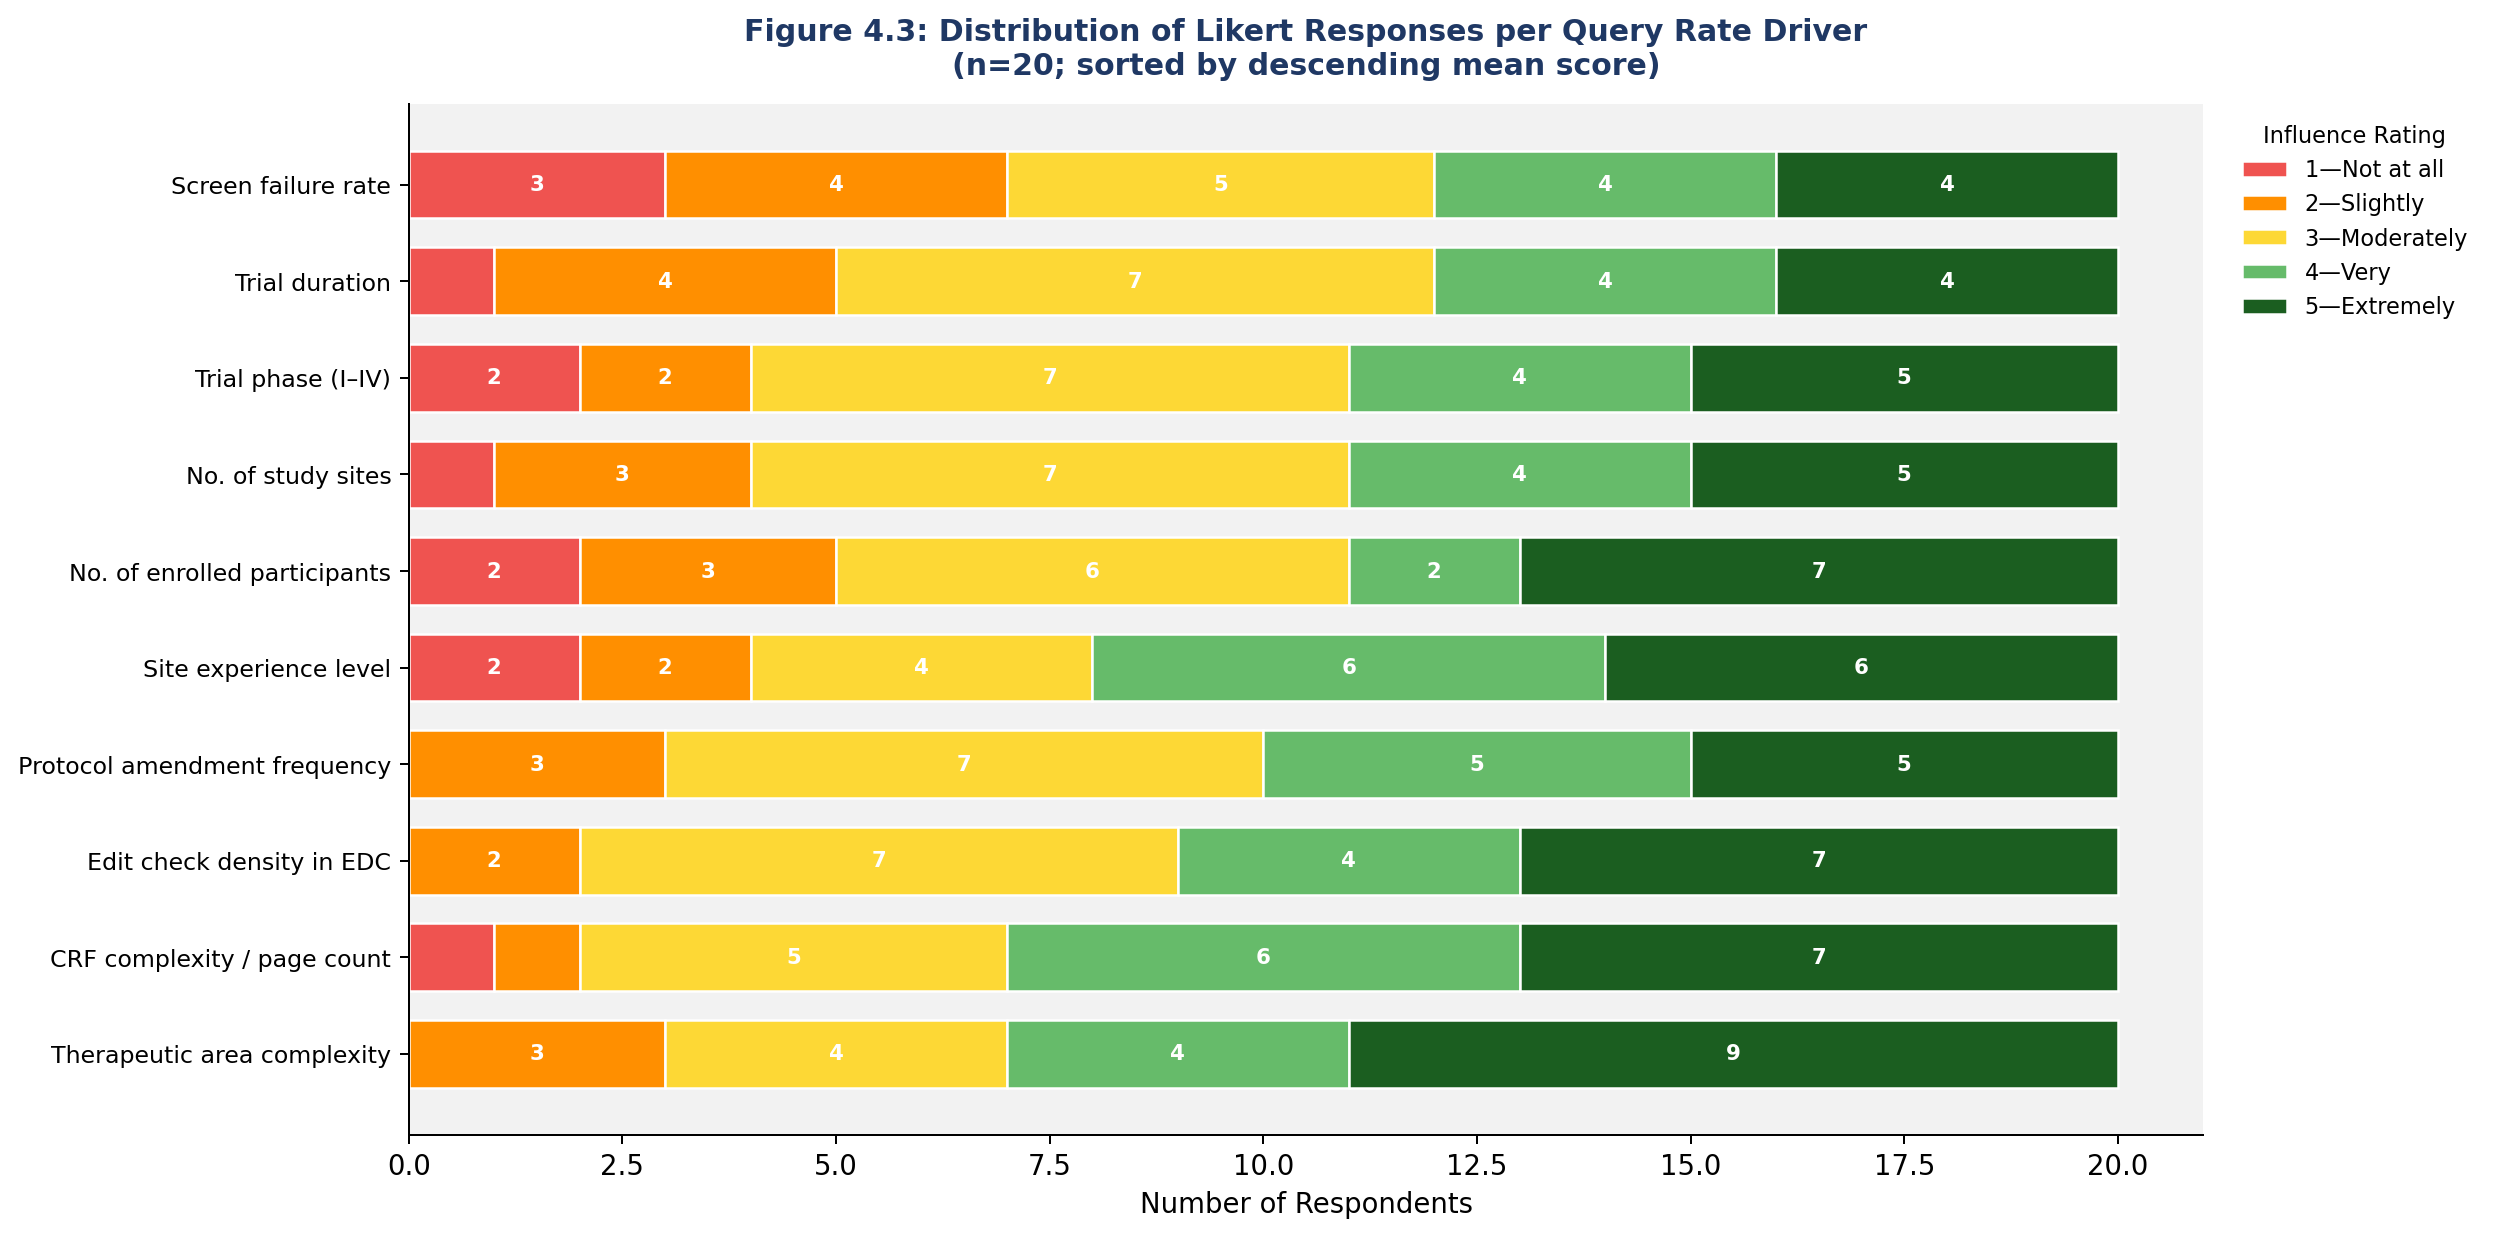

Figure 4.3 saved


In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

score_labels = ['1—Not at all', '2—Slightly', '3—Moderately', '4—Very', '5—Extremely']
score_colors = ['#EF5350', '#FF8F00', '#FDD835', '#66BB6A', '#1B5E20']

# Build distribution per factor
distributions = []
for col_idx in factor_col_indices:
    col = df.columns[col_idx]
    scores = df[col].map(score_map).dropna()
    distributions.append([int((scores == s).sum()) for s in [1, 2, 3, 4, 5]])

# Sort by mean descending (same order as Figure 4.2)
sorted_idx   = sorted(range(len(means)), key=lambda i: -means[i])
sorted_names = [factor_names[i].replace('\n', ' ') for i in sorted_idx]
sorted_dists = [distributions[i] for i in sorted_idx]

y_pos = np.arange(len(sorted_names))
lefts = np.zeros(len(sorted_names))

for j, (label, color) in enumerate(zip(score_labels, score_colors)):
    vals = [d[j] for d in sorted_dists]
    bars = ax.barh(y_pos, vals, left=lefts, color=color,
                   label=label, edgecolor='white', height=0.7)
    for bar, val in zip(bars, vals):
        if val > 1:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_y()+bar.get_height()/2,
                    str(val), ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    lefts += np.array(vals)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names, fontsize=9.5)
ax.set_xlabel('Number of Respondents', fontsize=11)
ax.set_title(
    f'Figure 4.3: Distribution of Likert Responses per Query Rate Driver\n'
    f'(n={N}; sorted by descending mean score)',
    fontsize=12, fontweight='bold', color=C_DARK, pad=12
)
ax.legend(title='Influence Rating', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9, title_fontsize=9, frameon=False)
ax.set_facecolor(C_LGRAY)

plt.tight_layout()
plt.savefig('Fig4_3_Likert_Distribution.jpg', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4.3 saved')

## Cell 6 — Figure 4.6: Current Practices + Review Frequency

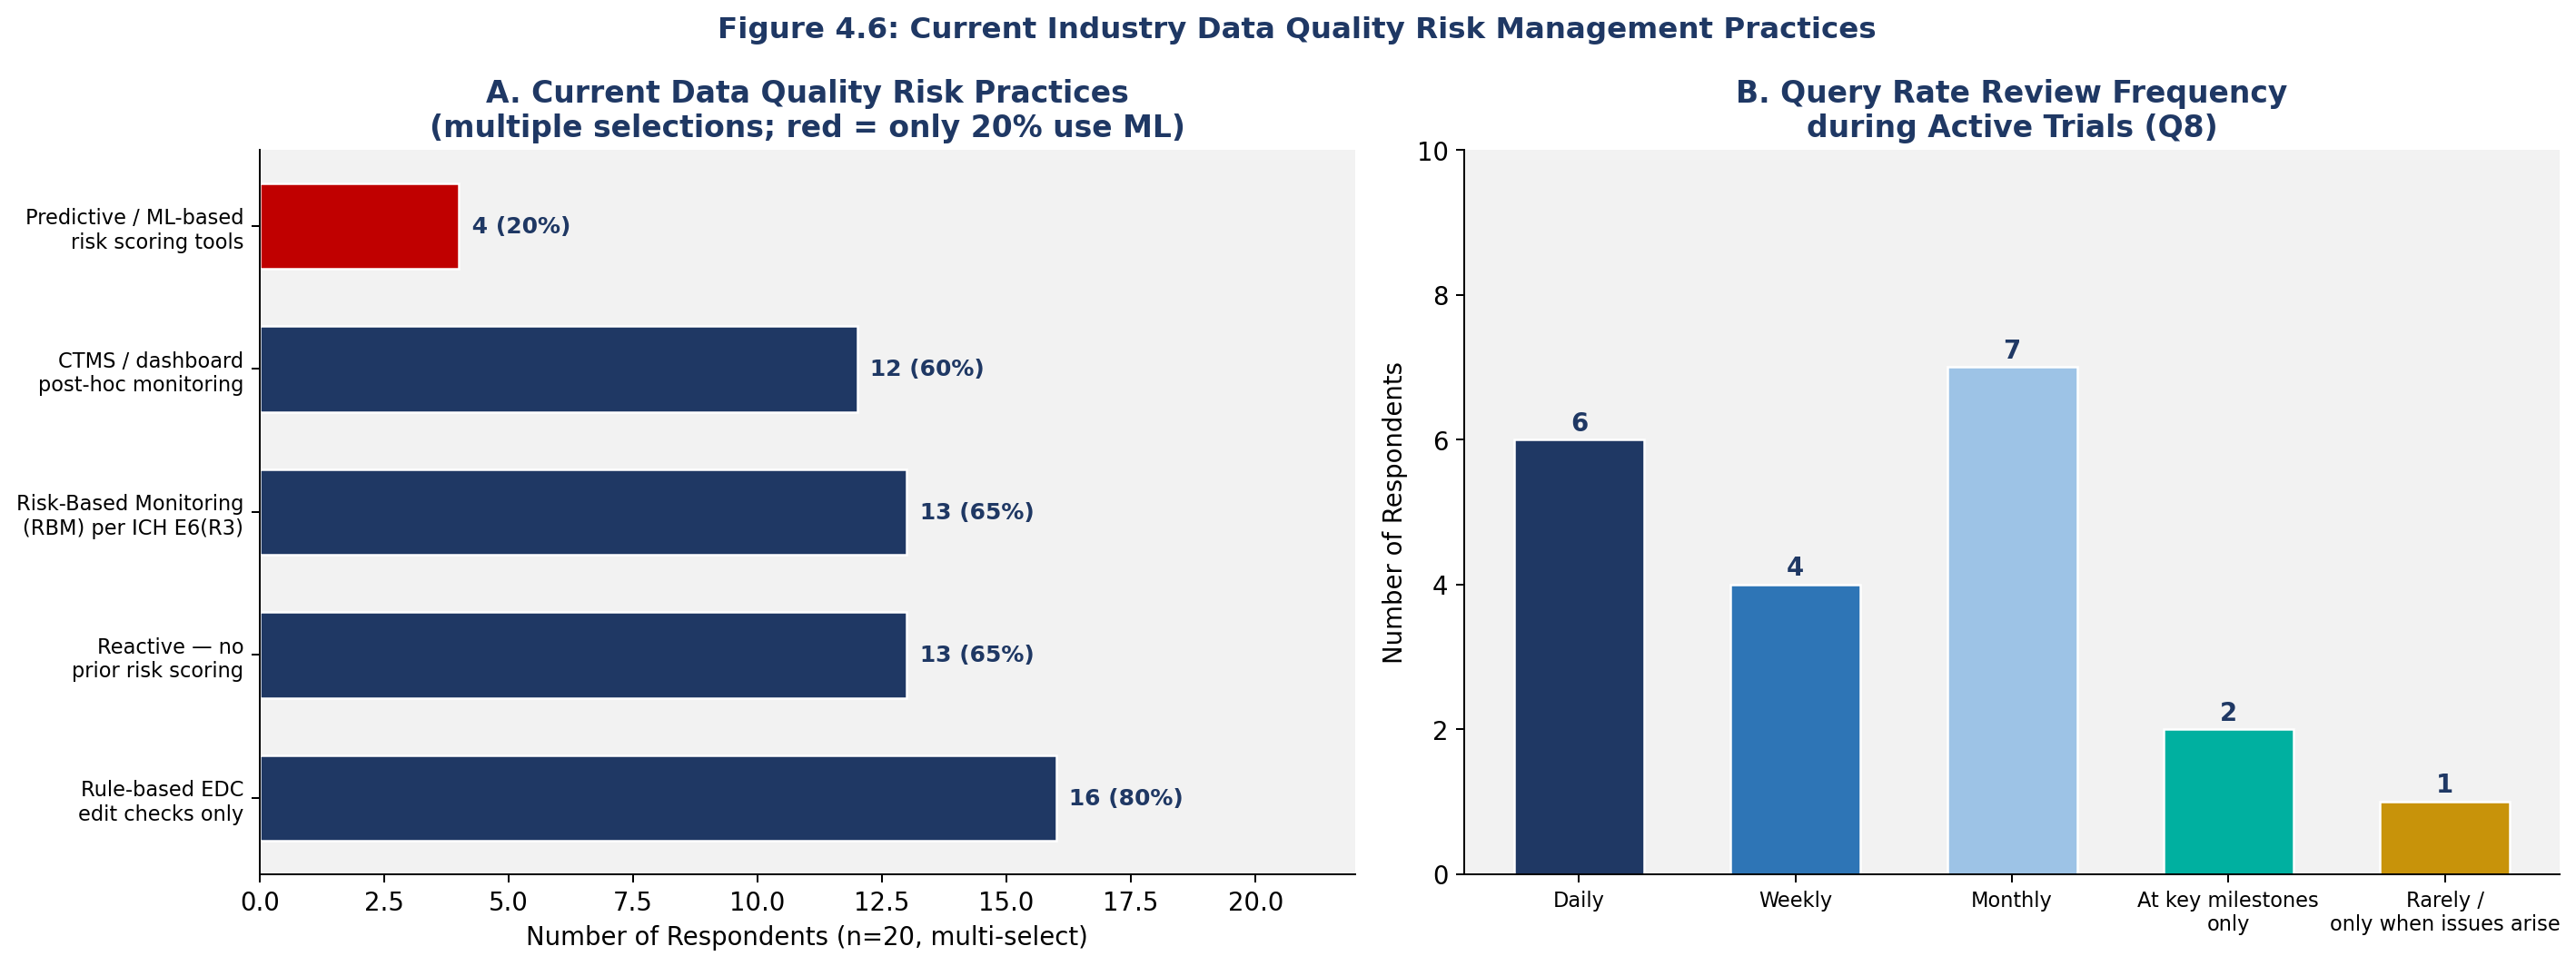

Figure 4.6 saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 4.6: Current Industry Data Quality Risk Management Practices',
             fontsize=13, fontweight='bold', color=C_DARK)

# Panel A — Q7 Current practices (col 23, multi-select)
# Count each practice across all multi-select responses
practice_keys = [
    'Rule-based EDC edit checks only',
    'Reactive — queries are raised and resolved as they arise with no prior risk scoring',
    'Risk-Based Monitoring (RBM) as per ICH E6(R3)',
    'CTMS / dashboard-based post-hoc monitoring',
    'Predictive / ML-based risk scoring tools'
]
practice_labels = [
    'Rule-based EDC\nedit checks only',
    'Reactive — no\nprior risk scoring',
    'Risk-Based Monitoring\n(RBM) per ICH E6(R3)',
    'CTMS / dashboard\npost-hoc monitoring',
    'Predictive / ML-based\nrisk scoring tools'
]
practice_vals = [df.iloc[:, 23].str.contains(k, na=False, regex=False).sum()
                 for k in practice_keys]

# Sort by count
sorted_pairs = sorted(zip(practice_labels, practice_vals), key=lambda x: x[1], reverse=True)
p_labels = [x[0] for x in sorted_pairs]
p_vals   = [x[1] for x in sorted_pairs]
p_colors = [C_RED if 'ML' in l else C_DARK for l in p_labels]

bars_a = axes[0].barh(p_labels, p_vals, color=p_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars_a, p_vals):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f' {val} ({val/N*100:.0f}%)', va='center', fontsize=10,
                 color=C_DARK, fontweight='bold')
axes[0].set_title('A. Current Data Quality Risk Practices\n(multiple selections; red = only 20% use ML)',
                  fontweight='bold', color=C_DARK)
axes[0].set_xlabel(f'Number of Respondents (n={N}, multi-select)')
axes[0].set_xlim(0, 22)
axes[0].set_facecolor(C_LGRAY)
axes[0].tick_params(axis='y', labelsize=9)

# Panel B — Q8 Review frequency (col 24)
freq_keys = [
    'Daily', 'Weekly', 'Monthly',
    'At key milestones only (e.g. interim analysis, database lock)',
    'Rarely / only when issues arise'
]
freq_labels = [
    'Daily', 'Weekly', 'Monthly',
    'At key milestones\nonly', 'Rarely /\nonly when issues arise'
]
freq_data = df.iloc[:, 24].value_counts()
freq_vals = [freq_data.get(k, 0) for k in freq_keys]

bars_b = axes[1].bar(freq_labels, freq_vals,
                     color=[C_DARK, C_MID, C_LIGHT, C_TEAL, C_AMBER],
                     edgecolor='white', width=0.6)
for bar, val in zip(bars_b, freq_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(val), ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color=C_DARK)
axes[1].set_title('B. Query Rate Review Frequency\nduring Active Trials (Q8)', fontweight='bold', color=C_DARK)
axes[1].set_ylabel('Number of Respondents')
axes[1].set_ylim(0, 10)
axes[1].set_facecolor(C_LGRAY)
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('Fig4_6_Current_Practices.jpg', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4.6 saved')

## Cell 7 — Figure 4.8: ML Familiarity + Agreement Score

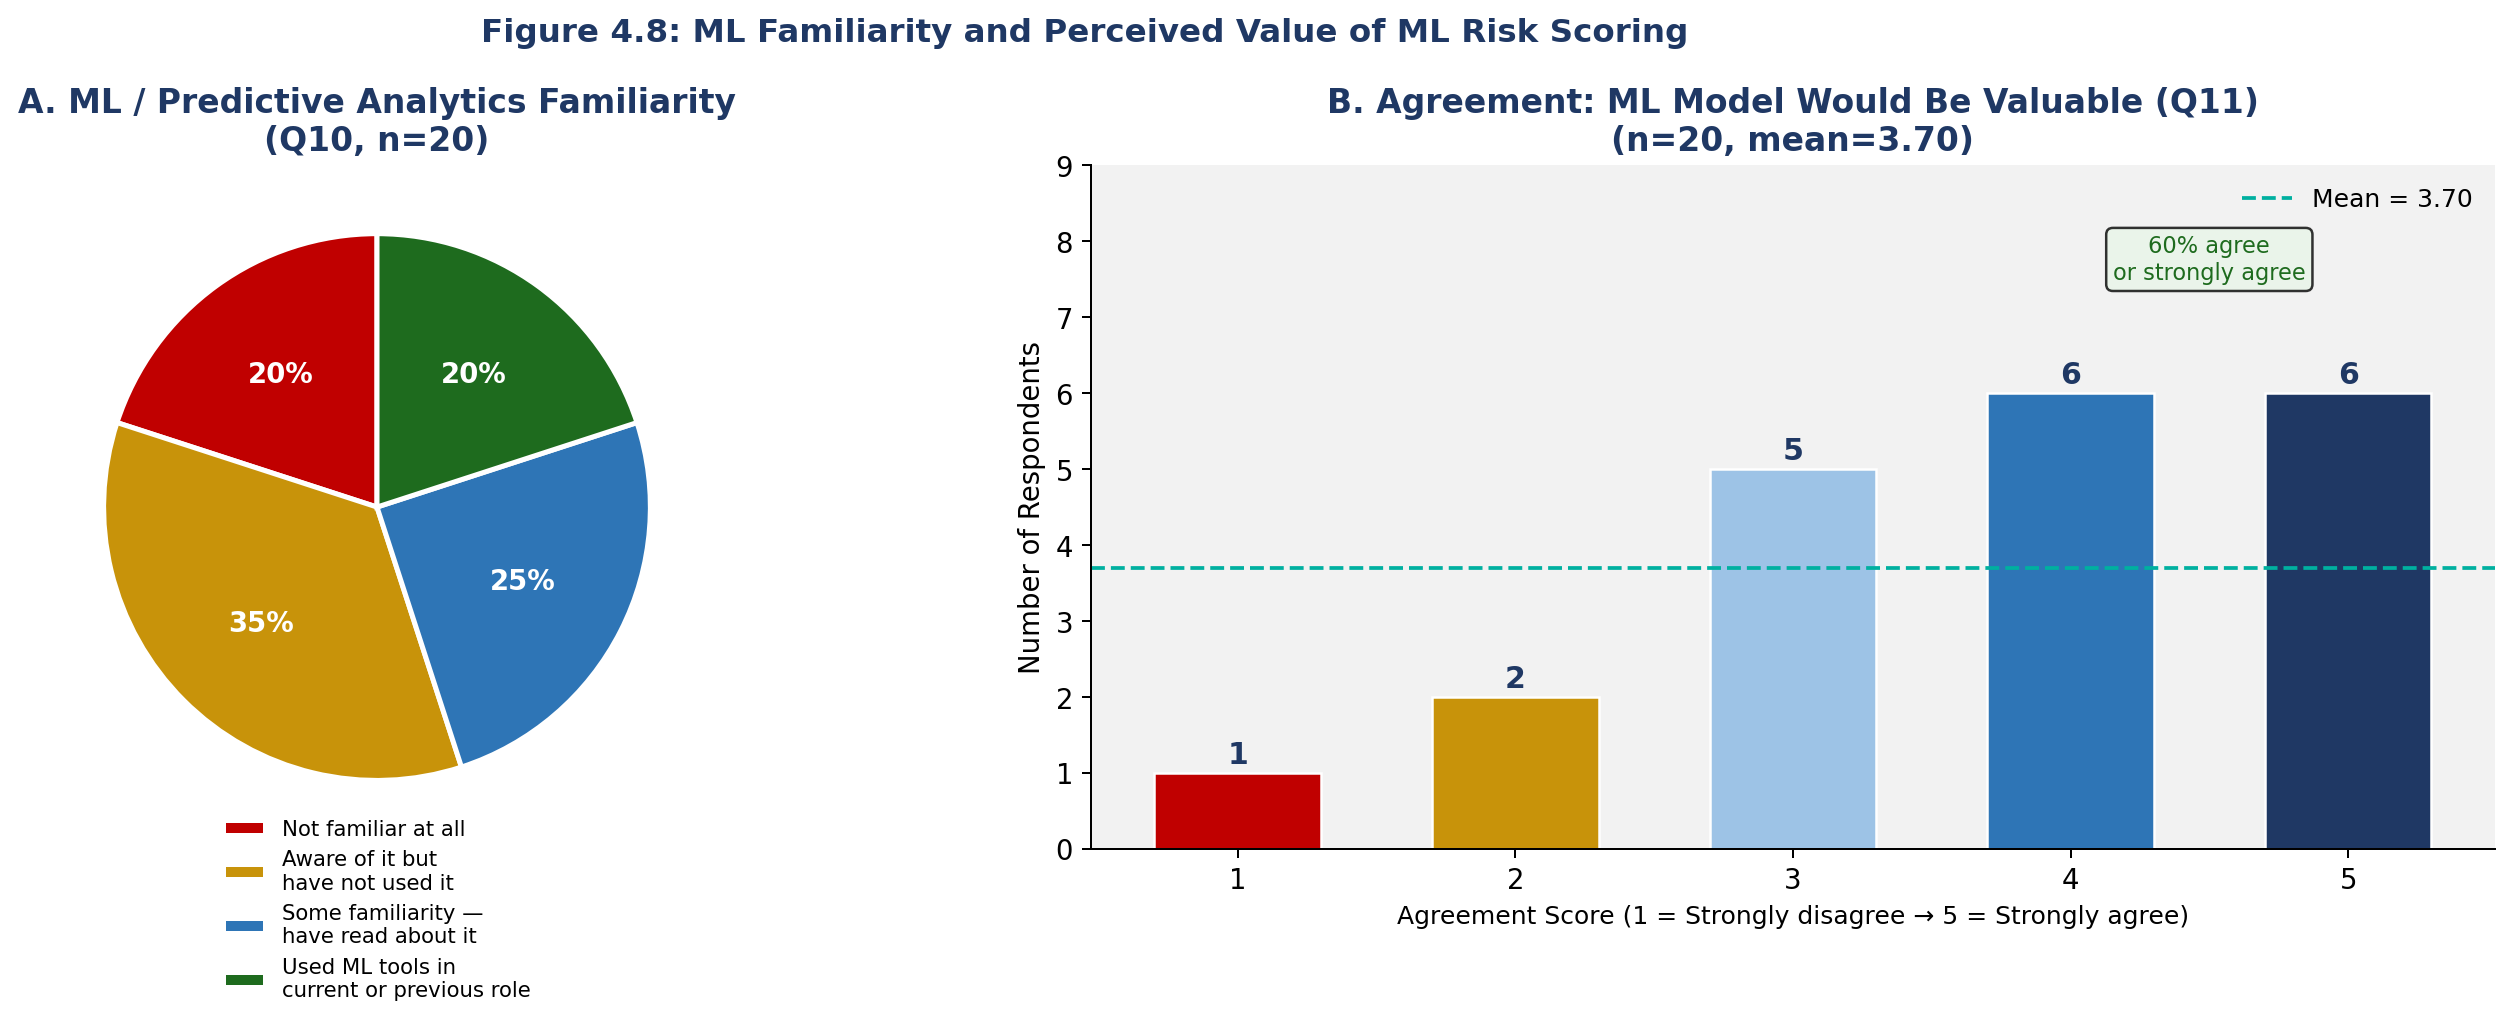

Figure 4.8 saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 4.8: ML Familiarity and Perceived Value of ML Risk Scoring',
             fontsize=13, fontweight='bold', color=C_DARK)

# Panel A — Q10 ML familiarity (col 26)
fam_keys = [
    'Not familiar at all',
    'Aware of it but have not used it',
    'Some familiarity — have read about it or seen it used',
    'Used ML tools in my current or previous role'
]
fam_labels = [
    'Not familiar at all',
    'Aware of it but\nhave not used it',
    'Some familiarity —\nhave read about it',
    'Used ML tools in\ncurrent or previous role'
]
fam_data = df.iloc[:, 26].value_counts()
fam_vals  = [fam_data.get(k, 0) for k in fam_keys]
fam_colors = [C_RED, C_AMBER, C_MID, C_GREEN]

wedges, texts, autotexts = axes[0].pie(
    fam_vals, labels=None, colors=fam_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
axes[0].legend(fam_labels, loc='lower center', fontsize=8.5,
               frameon=False, bbox_to_anchor=(0.5, -0.25))
axes[0].set_title('A. ML / Predictive Analytics Familiarity\n(Q10, n=20)', fontweight='bold', color=C_DARK)

# Panel B — Q11 Agreement score (col 27)
agree_scores = pd.to_numeric(df.iloc[:, 27], errors='coerce').dropna().astype(int)
score_counts = agree_scores.value_counts().sort_index()
agree_colors = [C_RED, C_AMBER, C_LIGHT, C_MID, C_DARK]

bars_b = axes[1].bar(score_counts.index, score_counts.values,
                     color=agree_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars_b, score_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(val), ha='center', va='bottom', fontsize=12,
                 fontweight='bold', color=C_DARK)

mean_score = agree_scores.mean()
axes[1].axhline(y=mean_score, color=C_TEAL, linestyle='--',
                linewidth=1.5, label=f'Mean = {mean_score:.2f}')
axes[1].set_xlabel('Agreement Score (1 = Strongly disagree → 5 = Strongly agree)', fontsize=10)
axes[1].set_ylabel('Number of Respondents')
axes[1].set_title(
    f'B. Agreement: ML Model Would Be Valuable (Q11)\n'
    f'(n={N}, mean={mean_score:.2f})',
    fontweight='bold', color=C_DARK
)
axes[1].set_ylim(0, 9)
axes[1].set_facecolor(C_LGRAY)
axes[1].legend(fontsize=10, frameon=False)
axes[1].set_xticks([1, 2, 3, 4, 5])

agree_pct = sum(1 for s in agree_scores if s >= 4) / len(agree_scores) * 100
axes[1].text(4.5, 7.5, f'{agree_pct:.0f}% agree\nor strongly agree',
             fontsize=9, color=C_GREEN, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', alpha=0.8))

plt.tight_layout()
plt.savefig('Fig4_8_ML_Familiarity_Agreement.jpg', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4.8 saved')

## Cell 8 — Figure 4.9: Preferred ML Outputs + Adoption Concerns

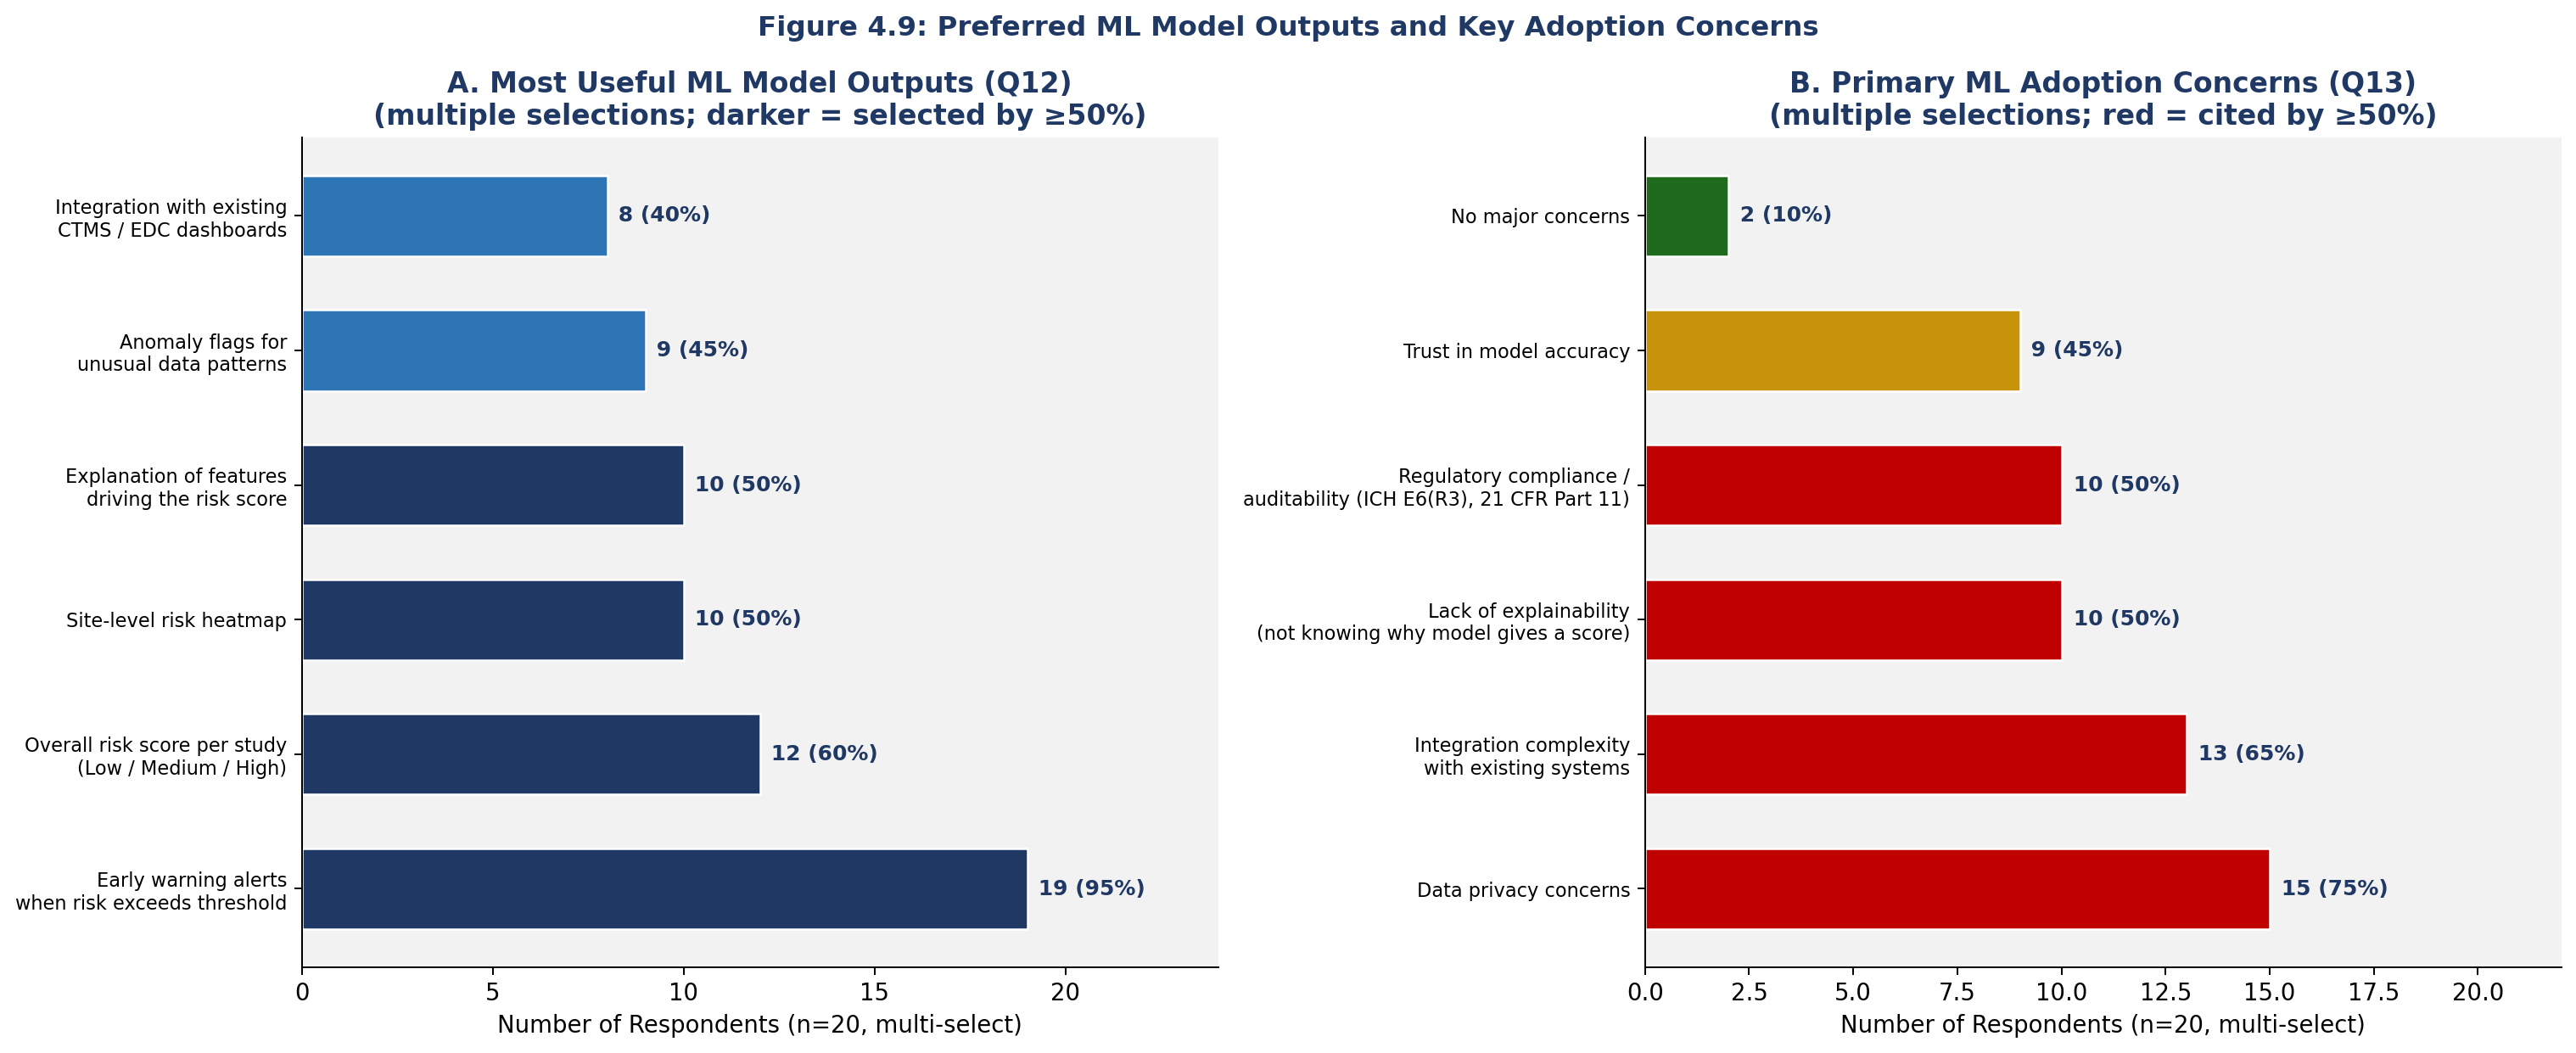

Figure 4.9 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Figure 4.9: Preferred ML Model Outputs and Key Adoption Concerns',
             fontsize=13, fontweight='bold', color=C_DARK)

# Panel A — Q12 ML outputs (col 28, multi-select)
output_keys = [
    'Early warning alerts when risk exceeds a threshold',
    'Overall risk score per study (Low / Medium / High)',
    'Site-level risk heatmap',
    'Explanation of which features are driving the risk score',
    'Anomaly flags for unusual data patterns',
    'Integration with existing CTMS / EDC dashboards'
]
output_labels = [
    'Early warning alerts\nwhen risk exceeds threshold',
    'Overall risk score per study\n(Low / Medium / High)',
    'Site-level risk heatmap',
    'Explanation of features\ndriving the risk score',
    'Anomaly flags for\nunusual data patterns',
    'Integration with existing\nCTMS / EDC dashboards'
]
output_vals = [df.iloc[:, 28].str.contains(k, na=False, regex=False).sum()
               for k in output_keys]

sorted_out = sorted(zip(output_labels, output_vals), key=lambda x: x[1], reverse=True)
o_labels = [x[0] for x in sorted_out]
o_vals   = [x[1] for x in sorted_out]
o_colors = [C_DARK if v >= 10 else C_MID for v in o_vals]

bars_a = axes[0].barh(o_labels, o_vals, color=o_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars_a, o_vals):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f' {val} ({val/N*100:.0f}%)', va='center', fontsize=10,
                 fontweight='bold', color=C_DARK)
axes[0].set_title('A. Most Useful ML Model Outputs (Q12)\n(multiple selections; darker = selected by ≥50%)',
                  fontweight='bold', color=C_DARK)
axes[0].set_xlabel(f'Number of Respondents (n={N}, multi-select)')
axes[0].set_xlim(0, 24)
axes[0].set_facecolor(C_LGRAY)
axes[0].tick_params(axis='y', labelsize=9)

# Panel B — Q13 Concerns (col 29, multi-select)
concern_keys = [
    'Data privacy concerns',
    'Integration complexity with existing systems',
    'Lack of explainability — not knowing why the model gives a score',
    'Regulatory compliance / auditability under ICH E6(R3) or FDA 21 CFR Part 11',
    'Trust in model accuracy',
    'No major concerns'
]
concern_labels = [
    'Data privacy concerns',
    'Integration complexity\nwith existing systems',
    'Lack of explainability\n(not knowing why model gives a score)',
    'Regulatory compliance /\nauditability (ICH E6(R3), 21 CFR Part 11)',
    'Trust in model accuracy',
    'No major concerns'
]
concern_vals = [df.iloc[:, 29].str.contains(k, na=False, regex=False).sum()
                for k in concern_keys]

sorted_con = sorted(zip(concern_labels, concern_vals), key=lambda x: x[1], reverse=True)
c_labels = [x[0] for x in sorted_con]
c_vals   = [x[1] for x in sorted_con]
c_colors = [C_RED if v >= 10 else (C_AMBER if v >= 5 else C_GREEN) for v in c_vals]

bars_b = axes[1].barh(c_labels, c_vals, color=c_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars_b, c_vals):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f' {val} ({val/N*100:.0f}%)', va='center', fontsize=10,
                 fontweight='bold', color=C_DARK)
axes[1].set_title('B. Primary ML Adoption Concerns (Q13)\n(multiple selections; red = cited by ≥50%)',
                  fontweight='bold', color=C_DARK)
axes[1].set_xlabel(f'Number of Respondents (n={N}, multi-select)')
axes[1].set_xlim(0, 22)
axes[1].set_facecolor(C_LGRAY)
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('Fig4_9_ML_Outputs_Concerns.jpg', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4.9 saved')

## Cell 9 — Figure 4.16: SHAP vs Survey Triangulation

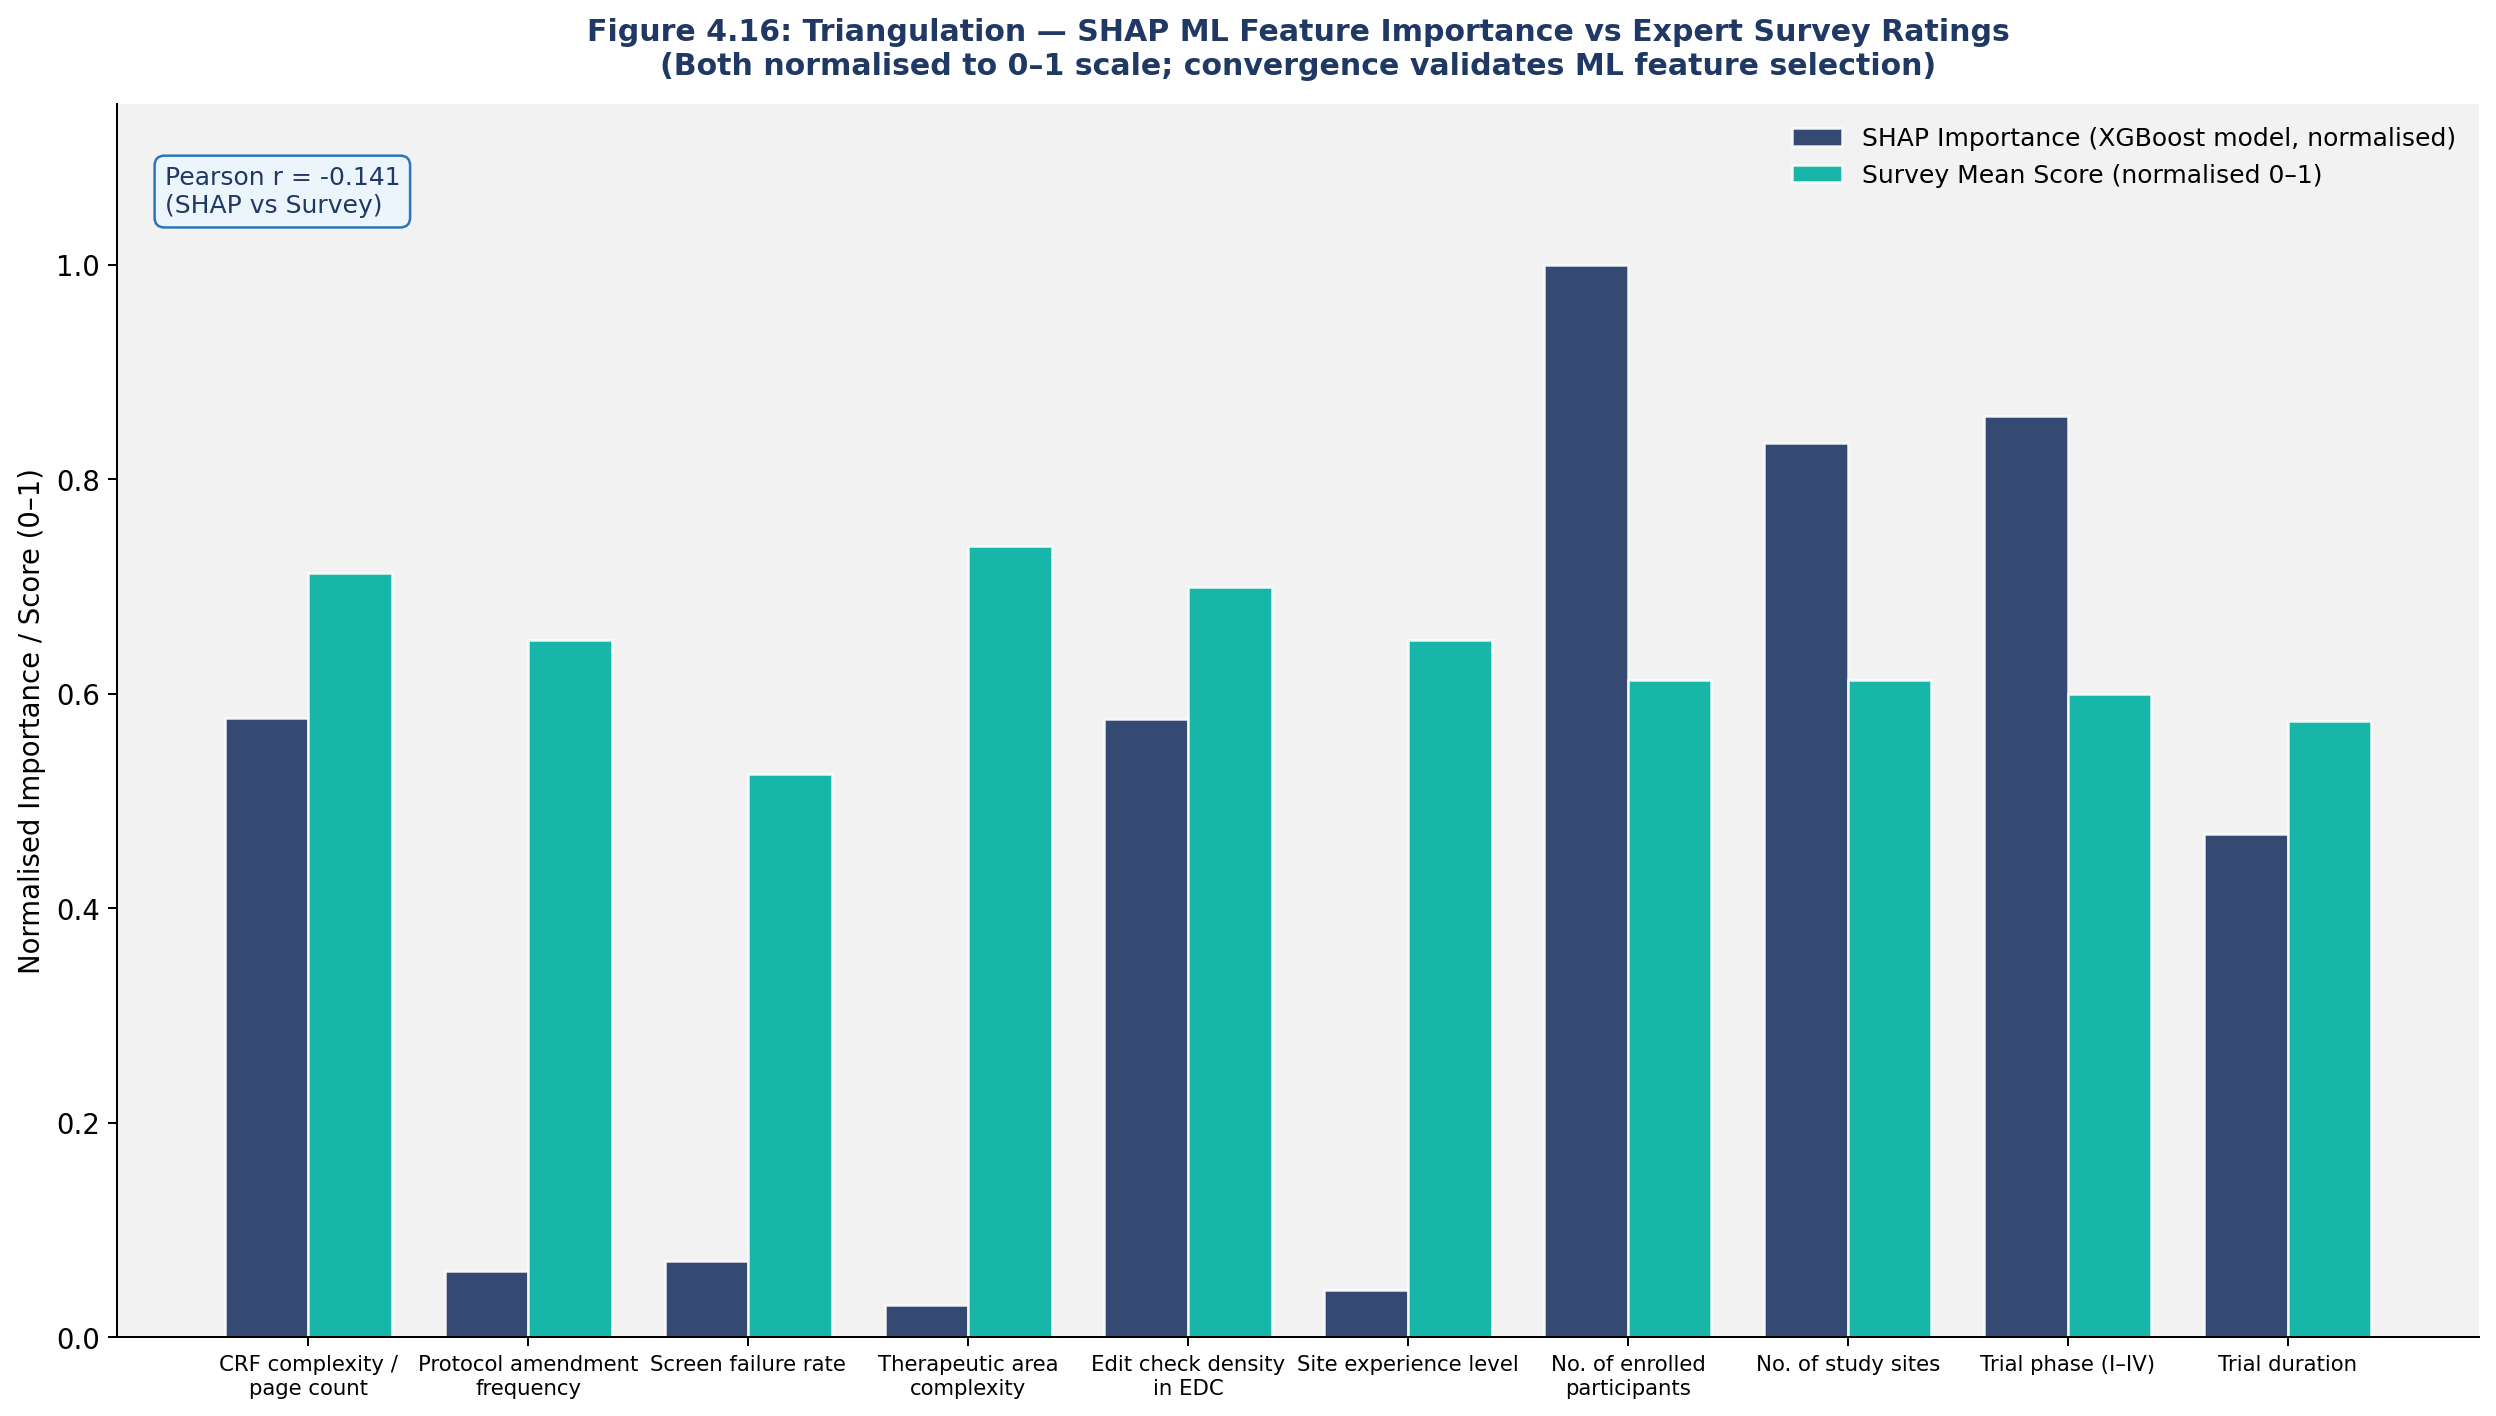

Pearson r = -0.141
Weak correlation — significant divergence between expert opinion and model

Key divergences to discuss in Chapter 4:
  Protocol amendment frequency: Survey rates higher (SHAP=0.062, Survey=0.650)
  Screen failure rate: Survey rates higher (SHAP=0.071, Survey=0.525)
  Therapeutic area complexity: Survey rates higher (SHAP=0.030, Survey=0.738)
  Site experience level: Survey rates higher (SHAP=0.044, Survey=0.650)
  No. of enrolled participants: Model rates higher (SHAP=1.000, Survey=0.613)
  No. of study sites: Model rates higher (SHAP=0.834, Survey=0.613)
  Trial phase (I–IV): Model rates higher (SHAP=0.859, Survey=0.600)
Figure 4.16 saved

Spearman rho = -0.329,  p = 0.353
Result: Non-significant — divergence is genuine, not sampling artefact


In [12]:
# Note: SHAP values represent mean absolute SHAP for the HIGH risk class
# Source: df_shap_samples exported from Thesis_Notebook_4 (HIGH class = index 2)
shap_features = [
    'CRF complexity /\npage count',
    'Protocol amendment\nfrequency',
    'Screen failure rate',
    'Therapeutic area\ncomplexity',
    'Edit check density\nin EDC',
    'Site experience level',
    'No. of enrolled\nparticipants',
    'No. of study sites',
    'Trial phase (I–IV)',
    'Trial duration'
]

# Therapeutic area: summed across all 9 one-hot encoded TA columns
# Trial phase: summed across all 6 one-hot encoded phase columns
# Source: shap_values_xgboost.csv (HIGH risk class, Notebook 4)

shap_vals = [
    0.207066,  # CRF complexity / page count
    0.022307,  # Protocol amendment frequency
    0.025338,  # Screen failure rate
    0.010747,  # Therapeutic area complexity (sum of all 9 TA columns)
    0.206778,  # Edit check density in EDC
    0.015748,  # Site experience level
    0.358451,  # No. of enrolled participants
    0.298803,  # No. of study sites
    0.308041,  # Trial phase I–IV (sum of all 6 phase columns)
    0.168385   # Trial duration
]

# Survey means for the same features (from our analysis above)
feature_to_mean = {
    'CRF complexity /\npage count':    3.85,
    'Protocol amendment\nfrequency':   3.60,
    'Screen failure rate':             3.10,
    'Therapeutic area\ncomplexity':    3.95,
    'Edit check density\nin EDC':      3.80,
    'Site experience level':           3.60,
    'No. of enrolled\nparticipants':   3.45,
    'No. of study sites':              3.45,
    'Trial phase (I–IV)':             3.40,
    'Trial duration':                  3.30
}
survey_raw  = [feature_to_mean[f] for f in shap_features]
survey_norm = [(s - 1) / 4 for s in survey_raw]  # normalise 1-5 to 0-1

# Normalise SHAP to 0-1 for fair comparison
shap_max   = max(shap_vals)
shap_norm  = [v / shap_max for v in shap_vals]

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(shap_features))
width = 0.38

bars1 = ax.bar(x - width/2, shap_norm,   width,
               label='SHAP Importance (XGBoost model, normalised)',
               color=C_DARK, edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, survey_norm, width,
               label='Survey Mean Score (normalised 0–1)',
               color=C_TEAL, edgecolor='white', alpha=0.9)

# Pearson correlation
r = np.corrcoef(shap_norm, survey_norm)[0, 1]
ax.text(0.02, 0.95, f'Pearson r = {r:.3f}\n(SHAP vs Survey)',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB', edgecolor=C_MID),
        color=C_DARK, va='top')

ax.set_xticks(x)
ax.set_xticklabels(shap_features, fontsize=8.5)
ax.set_ylabel('Normalised Importance / Score (0–1)', fontsize=11)
ax.set_title(
    'Figure 4.16: Triangulation — SHAP ML Feature Importance vs Expert Survey Ratings\n'
    '(Both normalised to 0–1 scale; convergence validates ML feature selection)',
    fontsize=12, fontweight='bold', color=C_DARK, pad=12
)
ax.legend(fontsize=10, frameon=False, loc='upper right')
ax.set_facecolor(C_LGRAY)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('Fig4_16_SHAP_vs_Survey_Triangulation.jpg', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

# Statistical interpretation of SHAP vs Survey correlation
r = np.corrcoef(shap_norm, survey_norm)[0, 1]
print(f"Pearson r = {r:.3f}")
if r >= 0.7:
    print("Strong positive correlation — survey and model largely agree")
elif r >= 0.4:
    print("Moderate positive correlation — partial agreement with notable divergences")
else:
    print("Weak correlation — significant divergence between expert opinion and model")

print("\nKey divergences to discuss in Chapter 4:")
for feat, sv, surv in zip(shap_features, shap_norm, survey_norm):
    diff = abs(sv - surv)
    if diff > 0.2:
        direction = "Model rates higher" if sv > surv else "Survey rates higher"
        print(f"  {feat.replace(chr(10),' ')}: {direction} (SHAP={sv:.3f}, Survey={surv:.3f})")

print(f'Figure 4.16 saved')

# Compute Spearman rank correlation (for Chapter 4 / Notebook 6)

from scipy import stats

# Use rank order of the normalised values
shap_rank_order   = stats.rankdata(shap_norm)
survey_rank_order = stats.rankdata(survey_norm)

rho, p_val = stats.spearmanr(shap_norm, survey_norm)
print(f"\nSpearman rho = {rho:.3f},  p = {p_val:.3f}")

if p_val < 0.05:
    print("Result: Statistically significant")
else:
    print("Result: Non-significant — divergence is genuine, not sampling artefact")

## Cell 10 — Figure 4.7: Stage of Discovery + Open Text Themes

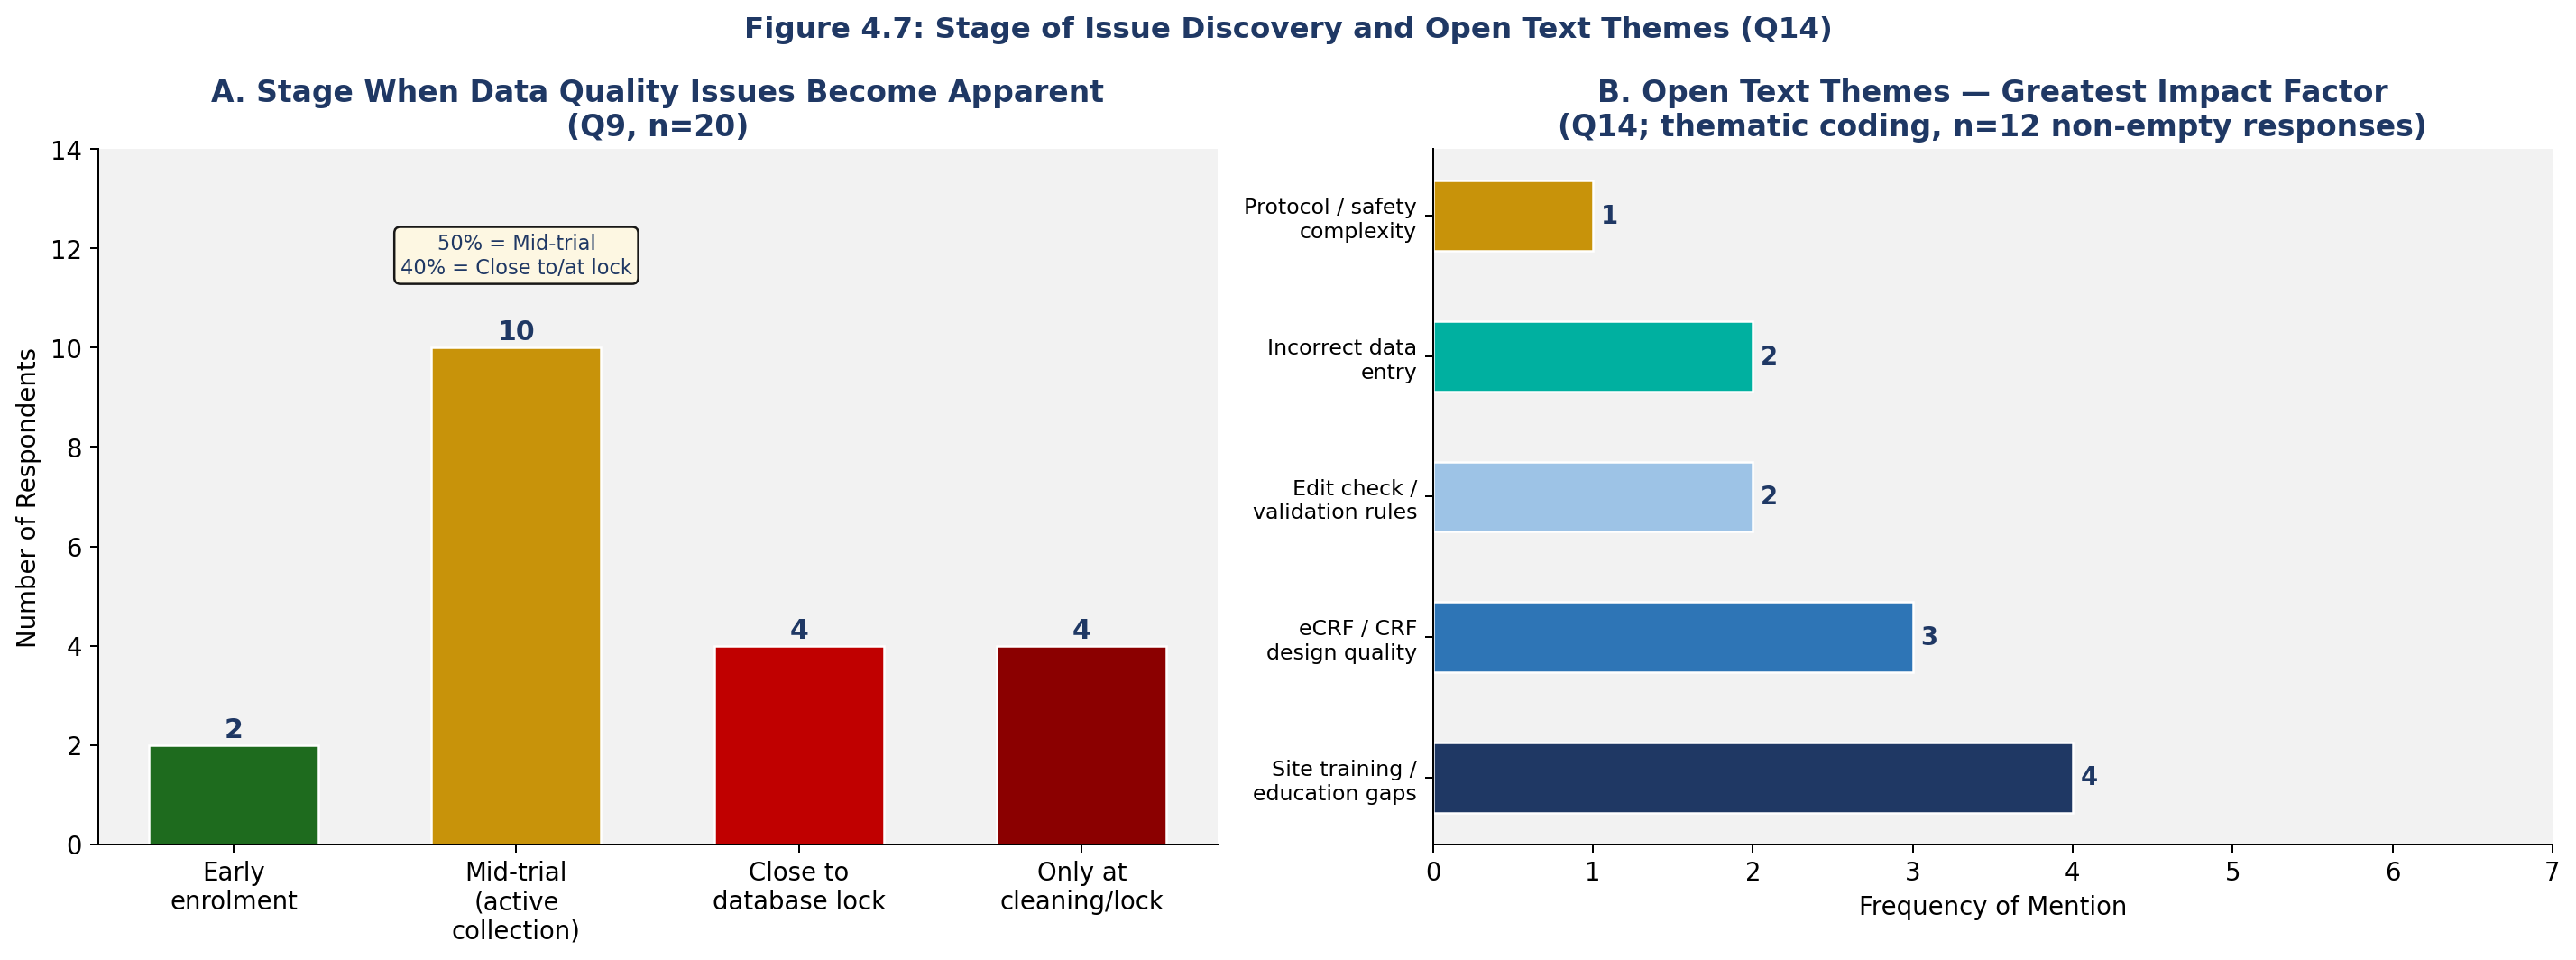

Figure 4.7 saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 4.7: Stage of Issue Discovery and Open Text Themes (Q14)',
             fontsize=13, fontweight='bold', color=C_DARK)

# Panel A — Q9 Stage when issues appear (col 25)
stage_keys = [
    'Early enrolment phase',
    'Mid-trial (active data collection)',
    'Close to database lock',
    'Only identified during data cleaning / lock'
]
stage_short = ['Early\nenrolment', 'Mid-trial\n(active\ncollection)',
               'Close to\ndatabase lock', 'Only at\ncleaning/lock']
stage_data = df.iloc[:, 25].value_counts()
stage_vals = [stage_data.get(k, 0) for k in stage_keys]

bars_a = axes[0].bar(stage_short, stage_vals,
                     color=[C_GREEN, C_AMBER, C_RED, '#8B0000'],
                     edgecolor='white', width=0.6)
for bar, val in zip(bars_a, stage_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(val), ha='center', va='bottom', fontsize=12,
                 fontweight='bold', color=C_DARK)
axes[0].set_ylabel('Number of Respondents')
axes[0].set_title('A. Stage When Data Quality Issues Become Apparent\n(Q9, n=20)',
                  fontweight='bold', color=C_DARK)
axes[0].set_ylim(0, 14)
axes[0].set_facecolor(C_LGRAY)
axes[0].text(1, 11.5, '50% = Mid-trial\n40% = Close to/at lock',
             fontsize=9, color=C_DARK, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF8E1', alpha=0.9))

# Panel B — Q14 open text thematic coding
# Manually coded from the 12 non-empty responses
themes = {
    'Site training /\neducation gaps': 4,
    'eCRF / CRF\ndesign quality': 3,
    'Edit check /\nvalidation rules': 2,
    'Incorrect data\nentry': 2,
    'Protocol / safety\ncomplexity': 1
}
sorted_t = dict(sorted(themes.items(), key=lambda x: x[1], reverse=True))
bars_b = axes[1].barh(list(sorted_t.keys()), list(sorted_t.values()),
                      color=[C_DARK, C_MID, C_LIGHT, C_TEAL, C_AMBER],
                      edgecolor='white', height=0.5)
for bar, val in zip(bars_b, sorted_t.values()):
    axes[1].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=11,
                 fontweight='bold', color=C_DARK)
axes[1].set_title('B. Open Text Themes — Greatest Impact Factor\n(Q14; thematic coding, n=12 non-empty responses)',
                  fontweight='bold', color=C_DARK)
axes[1].set_xlabel('Frequency of Mention')
axes[1].set_xlim(0, 7)
axes[1].set_facecolor(C_LGRAY)
axes[1].tick_params(axis='y', labelsize=9.5)

plt.tight_layout()
plt.savefig('Fig4_7_Stage_OpenText.jpg', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4.7 saved')

## Cell 11 — Summary Statistics Table (for dissertation text)

In [ ]:
print('=' * 60)
print('SURVEY ANALYSIS SUMMARY')
print('=' * 60)
print(f'Total respondents (n): {N}')
print()
print('EXPERIENCE DISTRIBUTION:')
exp_data = df.iloc[:, 1].value_counts()
for k, v in exp_data.items():
    print(f'  {k}: {v} ({v/N*100:.0f}%)')
print()
print('TOP 3 QUERY RATE DRIVERS (Likert Q5):')
for i, (name, mean, std, rank) in enumerate(
        factor_summary[['Factor','Mean Score','Std Dev','Rank']].values[:3], 1):
    print(f'  {i}. {name}: mean={mean:.2f} (SD={std:.2f})')
print()
print('CURRENT PRACTICES (Q7, multi-select):')
print(f'  Rule-based EDC edit checks: 16 (80%)')
print(f'  Reactive approach: 13 (65%)')
print(f'  ML-based tools: 4 (20%)')
print()
agree_scores = pd.to_numeric(df.iloc[:, 27], errors='coerce').dropna()
print(f'ML VALUE AGREEMENT (Q11):')
print(f'  Mean score: {agree_scores.mean():.2f}/5')
print(f'  Agree/Strongly agree (4-5): {(agree_scores >= 4).sum()} ({(agree_scores >= 4).mean()*100:.0f}%)')
print()
print('TOP ML ADOPTION CONCERN (Q13):')
print('  Data privacy concerns: 15 (75%)')
print('  Lack of explainability: 10 (50%)')
print('  Regulatory compliance: 10 (50%)')
print()
print('ALL FIGURES SAVED:')
import os
for f in sorted(os.listdir('.')):
    if f.startswith('Fig4') and f.endswith('.jpg'):
        print(f'  {f}')